In [43]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import seaborn as sns

file = uproot.open("val_5M/HToBB_121.root")
print(file.keys())

['tree;1']


In [44]:
tree = file['tree;1']
print(tree.keys())

['part_px', 'part_py', 'part_pz', 'part_energy', 'part_deta', 'part_dphi', 'part_d0val', 'part_d0err', 'part_dzval', 'part_dzerr', 'part_charge', 'part_isChargedHadron', 'part_isNeutralHadron', 'part_isPhoton', 'part_isElectron', 'part_isMuon', 'label_QCD', 'label_Hbb', 'label_Hcc', 'label_Hgg', 'label_H4q', 'label_Hqql', 'label_Zqq', 'label_Wqq', 'label_Tbqq', 'label_Tbl', 'jet_pt', 'jet_eta', 'jet_phi', 'jet_energy', 'jet_nparticles', 'jet_sdmass', 'jet_tau1', 'jet_tau2', 'jet_tau3', 'jet_tau4', 'aux_genpart_eta', 'aux_genpart_phi', 'aux_genpart_pid', 'aux_genpart_pt', 'aux_truth_match']


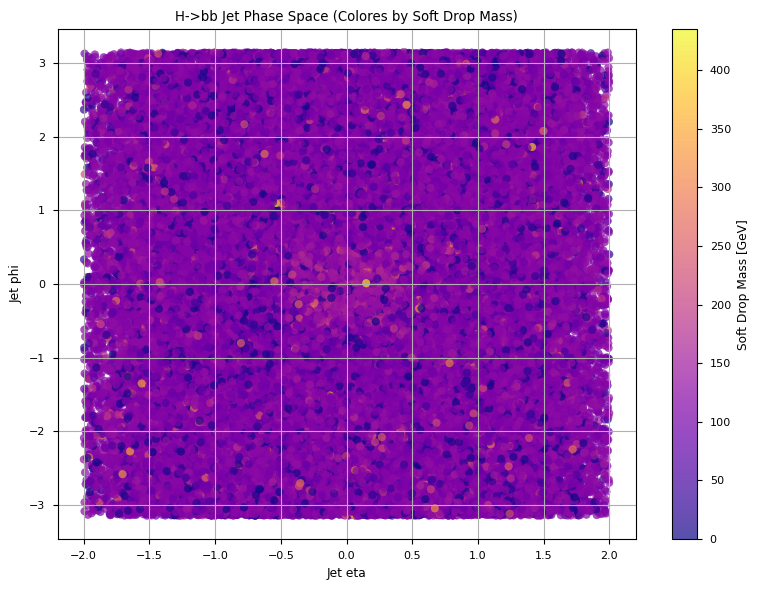

In [45]:
file = uproot.open("val_5M/HToBB_121.root")
tree = file["tree;1"]

branches = ['jet_eta', 'jet_phi', 'jet_sdmass', 'label_Hbb']
array = tree.arrays(branches)

eta = array['jet_eta']
phi = array['jet_phi']
mass = array['jet_sdmass']
label = array['label_Hbb']

mask = label == 1
eta = eta[mask]
phi = phi[mask]
mass = mass[mask]

plt.figure(figsize=(8,6))
scatter = plt.scatter(eta, phi, c=mass, cmap='plasma', alpha=0.7)
plt.xlabel("Jet eta")
plt.ylabel("Jet phi")
plt.title("H->bb Jet Phase Space (Colores by Soft Drop Mass)")
cbar = plt.colorbar(scatter)
cbar.set_label("Soft Drop Mass [GeV]")
plt.grid(True)
plt.tight_layout()
plt.show()

In [46]:
data_dir = "val_5M"

files = [
    "HToBB_121.root", "ZToQQ_121.root", "TTBar_121.root"
]

branches = [
    'jet_pt', 'jet_eta', 'jet_phi', 'jet_sdmass', 'jet_tau1', 'jet_tau2',
    'label_Hbb', 'label_Zqq', 'label_QCD'
]

df_list = []

for filename in files:
    path = os.path.join(data_dir, filename)
    tree = uproot.open(path)["tree"]
    array = tree.arrays(branches)
    df = ak.to_dataframe(array)

if "HToBB" in filename:
    df["class"] = "H->bb"
elif "ZToQQ" in filename:
    df["class"] = "Z->qq"
elif "TTBar" in filename:
    df["class"] = "QCD"
else:
    df["class"] = "Other"

df_list.append(df)

all_jets = pd.concat(df_list, ignore_index=True)

all_jets = all_jets[all_jets["jet_tau1"] > 0]
all_jets["tau21"] = all_jets["jet_tau2"] / all_jets["jet_tau1"]

print(all_jets.head())

       jet_pt   jet_eta   jet_phi  jet_sdmass  jet_tau1  jet_tau2  label_Hbb  \
0  818.043640  1.021991  2.767580   44.710297  0.088445  0.045340      False   
1  585.027954  1.167459  0.275085  187.393158  0.317223  0.157486      False   
2  638.494995 -0.235691  1.079777  191.541824  0.271773  0.137290      False   
3  703.955200  0.555541  0.476055  224.825043  0.316369  0.209474      False   
4  547.124512  0.826437 -2.472147  130.962585  0.277070  0.098839      False   

   label_Zqq  label_QCD class     tau21  
0          0        0.0   QCD  0.512637  
1          0        0.0   QCD  0.496453  
2          0        0.0   QCD  0.505164  
3          0        0.0   QCD  0.662119  
4          0        0.0   QCD  0.356729  


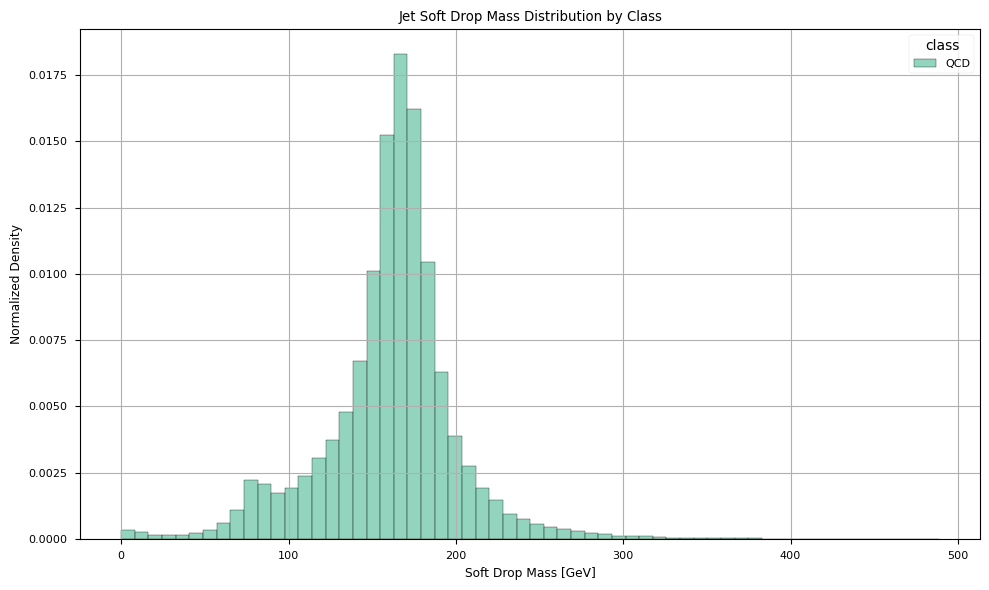

In [47]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=all_jets, x="jet_sdmass", hue="class",
    bins=60, kde=False, stat="density", common_norm=False,
    palette="Set2", alpha=0.7
)

plt.xlabel("Soft Drop Mass [GeV]")
plt.ylabel("Normalized Density")
plt.title("Jet Soft Drop Mass Distribution by Class")
plt.grid(True)
plt.tight_layout()
plt.show()

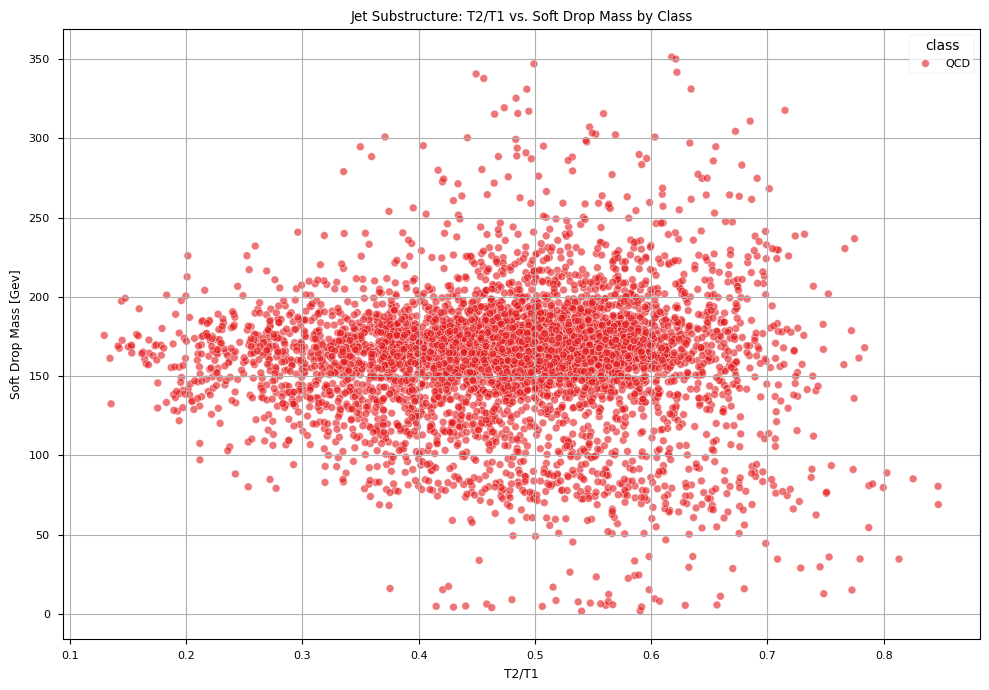

In [48]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=all_jets.sample(5000, random_state=42),
    x="tau21", y="jet_sdmass", hue="class", alpha=0.6,
    palette="Set1"
)

plt.xlabel("T2/T1")
plt.ylabel("Soft Drop Mass [Gev]")
plt.title("Jet Substructure: T2/T1 vs. Soft Drop Mass by Class")
plt.grid(True)
plt.tight_layout()
plt.show()

In [49]:
plt.style.use("seaborn-v0_8-paper")
plt.savefig("mass_vs_tau21.png", dpi=300)

<Figure size 640x440 with 0 Axes>

Skipping H→gg (no jets found)
Skipping Z→qq (no jets found)
Skipping W→qq (no jets found)
Skipping Top→bqq (no jets found)
Skipping QCD (no jets found)


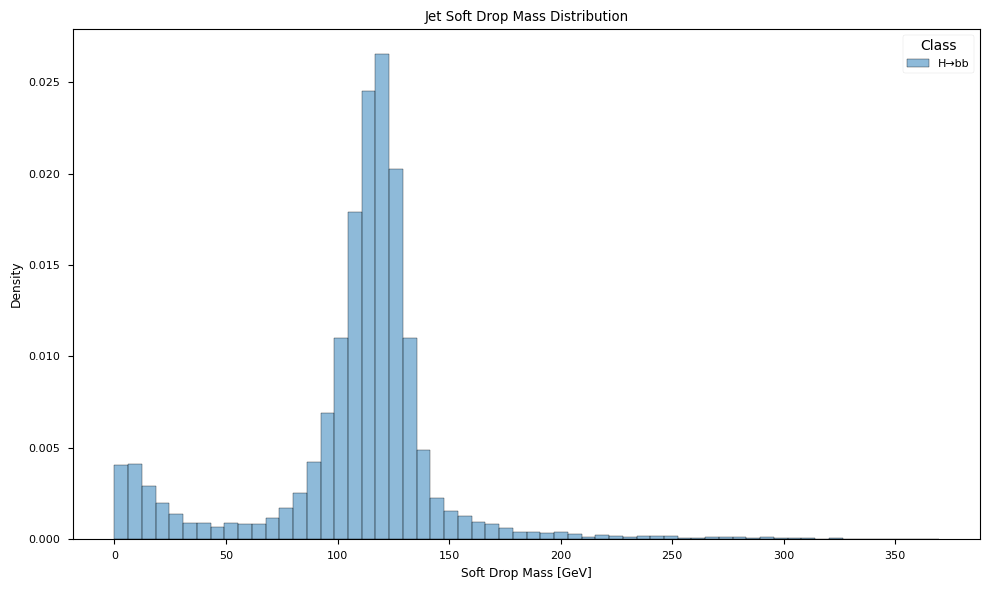

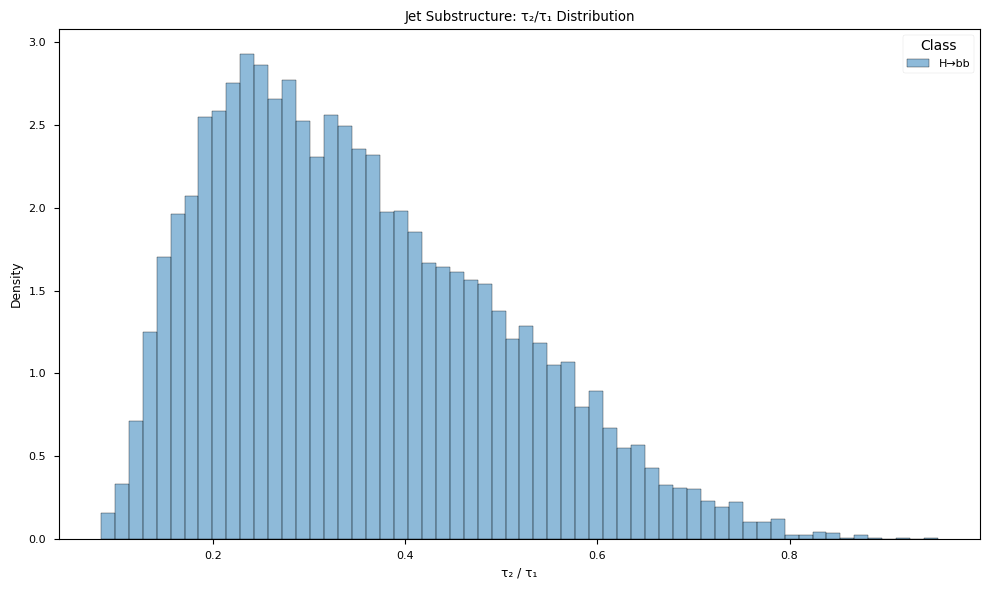

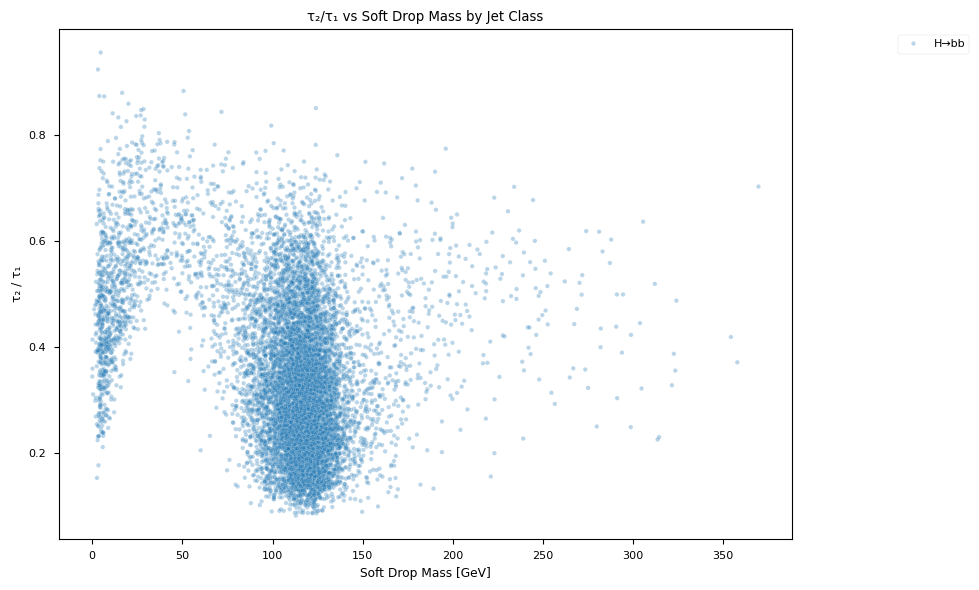

In [50]:
# SELECTING NEW CLASSSES TO PLOT FOR GREATER VARIETY

file_path = "/Users/jovannareyes/Desktop/jetclass_vscode/val_5M/HToBB_121.root"
file = uproot.open(file_path)
tree = file['tree;1']

features = [
    "jet_sdmass", "jet_tau1", "jet_tau2",
    "label_QCD", "label_Hbb", "label_Hgg", "label_Zqq",
    "label_Wqq", "label_Tbqq"
]

data = tree.arrays(features)

label_map = {
    "label_Hbb": "H→bb",
    "label_Hgg": "H→gg",
    "label_Zqq": "Z→qq",
    "label_Wqq": "W→qq",
    "label_Tbqq": "Top→bqq",
    "label_QCD": "QCD"
}

jets = []
for label_key, label_name in label_map.items():
    mask = data[label_key] == 1
    count = ak.sum(mask)
    if count == 0:
        print(f"Skipping {label_name} (no jets found)")
        continue
    n = min(10000, count)
    jets.append({
        "sdmass": data["jet_sdmass"][mask][:n],
        "tau1": data["jet_tau1"][mask][:n],
        "tau2": data["jet_tau2"][mask][:n],
        "label": np.full(n, label_name)
    })

all_sdmass = np.concatenate([ak.to_numpy(j["sdmass"]) for j in jets])
all_tau1 = np.concatenate([ak.to_numpy(j["tau1"]) for j in jets])
all_tau2 = np.concatenate([ak.to_numpy(j["tau2"]) for j in jets])
all_labels = np.concatenate([j["label"] for j in jets])

tau_ratio = all_tau2 / all_tau1

plt.figure(figsize=(10, 6))
sns.histplot(data={"Soft Drop Mass": all_sdmass, "Class": all_labels}, x="Soft Drop Mass", hue="Class", stat="density", common_norm=False, bins=60)
plt.title("Jet Soft Drop Mass Distribution")
plt.xlabel("Soft Drop Mass [GeV]")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# Plot: τ₂/τ₁
plt.figure(figsize=(10, 6))
sns.histplot(data={"τ₂/τ₁": tau_ratio, "Class": all_labels}, x="τ₂/τ₁", hue="Class", stat="density", common_norm=False, bins=60)
plt.title("Jet Substructure: τ₂/τ₁ Distribution")
plt.xlabel("τ₂ / τ₁")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# Plot: 2D scatter of τ₂/τ₁ vs soft drop mass
plt.figure(figsize=(10, 6))
sns.scatterplot(x=all_sdmass, y=tau_ratio, hue=all_labels, alpha=0.3, s=10)
plt.title("τ₂/τ₁ vs Soft Drop Mass by Jet Class")
plt.xlabel("Soft Drop Mass [GeV]")
plt.ylabel("τ₂ / τ₁")
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.show()

In [54]:
jet_data = jets[0]
mass = np.array(jet_data["sdmass"])
tau1 = np.array(jet_data["tau1"])
tau2 = np.array(jet_data["tau2"])
labels = np.array(jet_data["label"])


unique_labels = np.unique(labels)
print("Found classes:", unique_labels)


Found classes: ['H→bb']


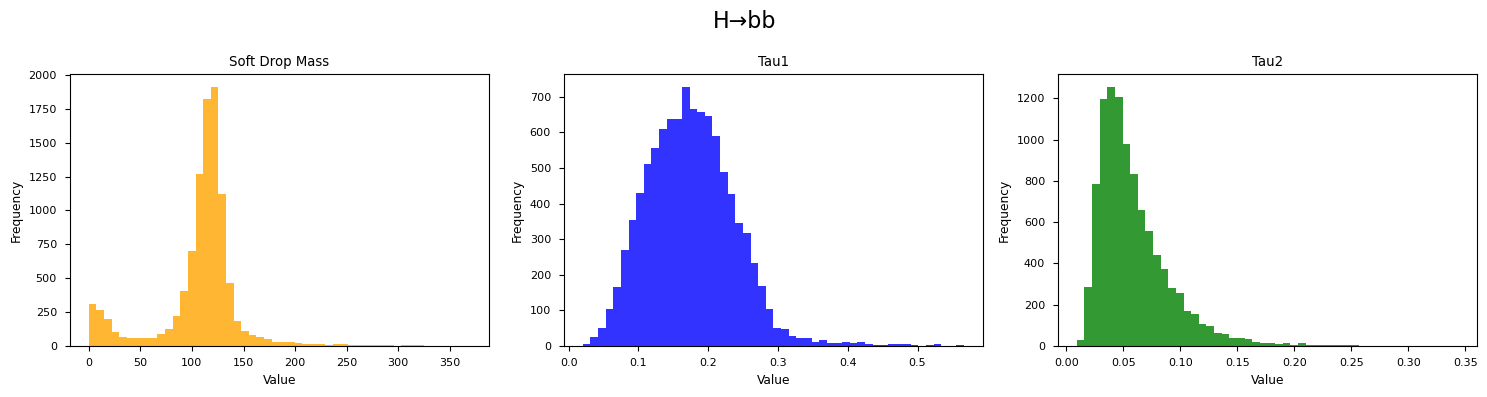

In [62]:

for label in unique_labels:
    indices = labels == label
    if np.sum(indices) == 0:
        print(f"Skipping {label} (no jets found)")
        continue

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"{label}", fontsize=16)

    axs[0].hist(mass[indices], bins=50, color='orange', alpha=0.8)
    axs[0].set_title("Soft Drop Mass")

    axs[1].hist(tau1[indices], bins=50, color='blue', alpha=0.8)
    axs[1].set_title("Tau1")

    axs[2].hist(tau2[indices], bins=50, color='green', alpha=0.8)
    axs[2].set_title("Tau2")

    for ax in axs:
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [ ]:
import os

print(os.listdir("val_5M"))



['TTBarLep_124.root', 'HToCC_120.root', 'HToWW2Q1L_124.root', 'WToQQ_121.root', 'HToWW4Q_123.root', 'HToWW4Q_122.root', 'ZJetsToNuNu_124.root', 'WToQQ_120.root', 'HToCC_121.root', 'TTBar_124.root', 'HToWW2Q1L_122.root', 'ZJetsToNuNu_123.root', 'ZToQQ_120.root', 'HToBB_120.root', 'TTBarLep_122.root', 'TTBar_123.root', 'HToGG_121.root', 'HToGG_120.root', 'TTBar_122.root', 'TTBarLep_123.root', 'HToBB_121.root', 'ZToQQ_121.root', 'HToWW4Q_124.root', 'ZJetsToNuNu_122.root', 'HToWW2Q1L_123.root', 'ZJetsToNuNu_121.root', 'HToWW2Q1L_120.root', 'HToCC_124.root', 'HToGG_123.root', 'TTBar_121.root', 'TTBarLep_120.root', 'HToBB_122.root', 'ZToQQ_122.root', 'ZToQQ_123.root', 'HToBB_123.root', 'TTBarLep_121.root', 'TTBar_120.root', 'HToGG_122.root', 'HToWW2Q1L_121.root', 'WToQQ_124.root', 'ZJetsToNuNu_120.root', 'HToBB_124.root', 'ZToQQ_124.root', 'HToWW4Q_121.root', 'WToQQ_123.root', 'HToCC_122.root', 'HToCC_123.root', 'WToQQ_122.root', 'HToWW4Q_120.root', 'HToGG_124.root']


In [52]:
print(type(jets))
print(len(jets))
print(jets[0])

<class 'list'>
1
{'sdmass': <Array [96.6, 116, 180, 85.2, ..., 8.53, 114, 106, 122] type='10000 * float32'>, 'tau1': <Array [0.19, 0.256, 0.233, ..., 0.1, 0.178, 0.218] type='10000 * float32'>, 'tau2': <Array [0.0622, 0.0884, 0.144, ..., 0.0963, 0.076] type='10000 * float32'>, 'label': array(['H→bb', 'H→bb', 'H→bb', ..., 'H→bb', 'H→bb', 'H→bb'], dtype='<U4')}
